# 4.1 Introduction to Differentiation 

In [1]:
using CairoMakie
using ForwardDiff
using Zygote
using Random
using Distributions

In the last few lectures, it was shown that in order to find the minimum of a function, we need to find the derivatives of a function.  There are a few methods of finding a derivatives of a function

* Manual
* Symbolic
* Numerical
* Automatic 

Manual differentiation is just what we learn in high school.  Symbolic differentiation is what computer can be programmed to do what we learn in high school.  Numerical differentiation is the finite difference approximation of a derivative.  Automatic differentiation is not usually talked about much but it is a development that has made many of the machine learning algorithms possible.  I will show you each of the different methods and how automatic differentiation is done in Julia.



Consider the function

$f(x)=\sin(x^2)$

Let's define and plot it to see how it looks like

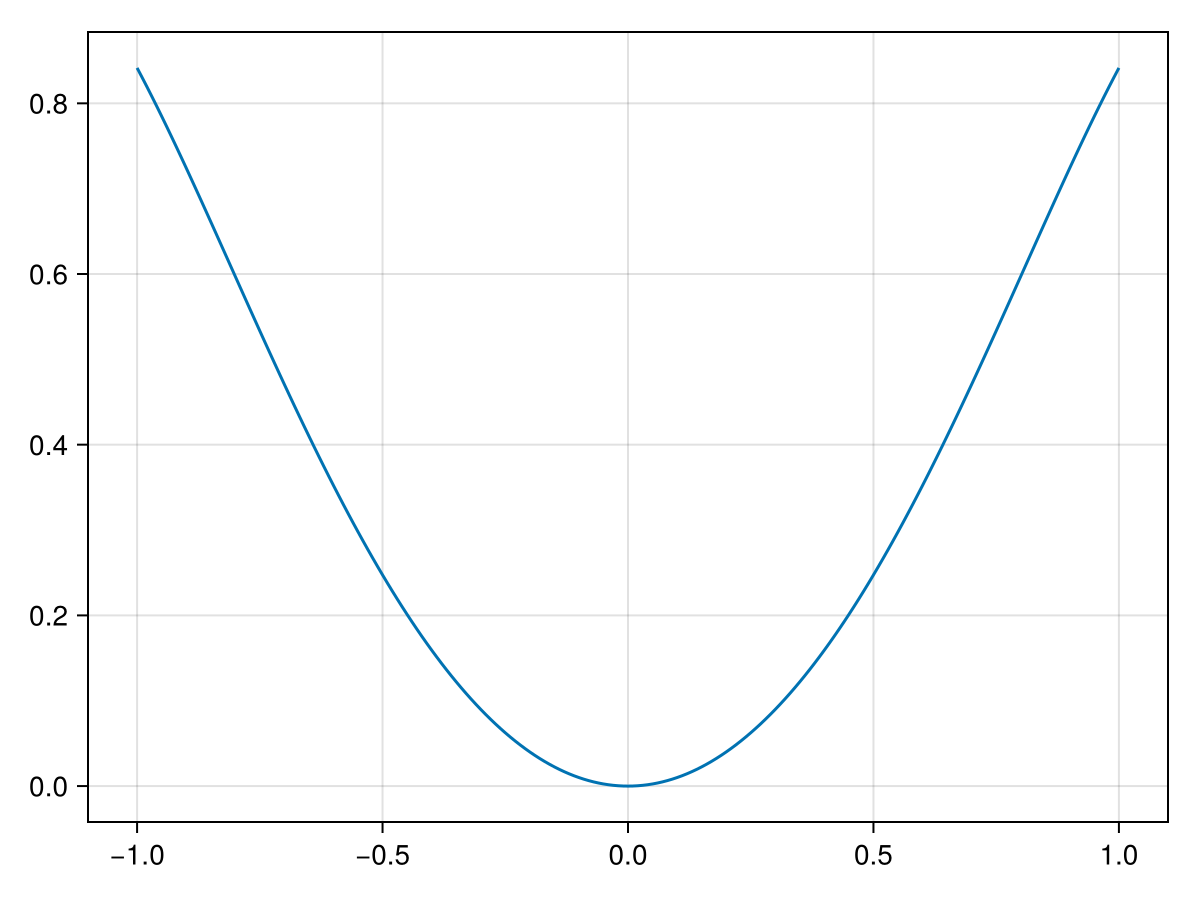

In [2]:
f(x)=sin(x^2);
xplot=-1:0.01:1
lines(xplot,f.(xplot))

Manual diffentiation is we apply the rules differentiation we learn in high school to get the derivative

$\frac{df}{dx}(x)=2x\cos(x^2)$

To perform Symbolic differentiation in Julia, first we need to import the Symoblics package

In [3]:
using Symbolics

In [4]:
# Define  x as a symbolic variable
@variables x

#Define the function.  Note that we cannot define f here because f has been defined as a function prior in the cell above
f1 = sin(x^2)

#Define a differential operator with respect to x
D=Differential(x)

#Expand the expression
expand_derivatives(D(f1))

2x*cos(x^2)

<u>Exercise Ex01:</u> Change code above to calculate the symbolic derivative $\sin(x^2)+\exp(-\cos(x))$.

Symbolic differentiation is feasible if you have a function that is not very complicated and also has only a few variables.  When you have a function of many variables (for real world problems, you can have millions or billions of variables/parameters), then computing symbolic derivatives can get very complicated and might not be possible.

Another way of computing derivatives is using numerical approximation.  You should know from other courses/subjects that the derivative of f at $x_i$ can be approximated as

* Forward differentiation: $\frac{df}{dx}(x_i)\approx (f(x_i+h)-f(x_i))/h$
* Backward differentiation: $\frac{df}{dx}(x_i)\approx (f(x_i)-f(x_i-h))/h$
* Central differentiation: $\frac{df}{dx}(x_i)\approx (f(x_i+h)-f(x_i-h))/(2h)$

where $h$ is a small number.

There is another way of numerically approximating the derivatives of a function which might not be commonly known.  This is the complex step method.  Consider Taylor expansion with an imaginary step $ih$ where $i$ is the imaginary unit. 

$f(x+ih)=f(x)+ih\frac{df}{dx}-\frac{h^2}{2!}\frac{d^2f}{dx^2}-\frac{ih^3}{3!}\frac{d^3f}{dx^3}+\cdots$

Consider now the Real and Imaginary parts of $f(x+ih)$

$\Re(f(x+ih))=f(x)-\frac{h^2}{2!}\frac{d^2f}{dx^2}+\cdots$

$\Im(f(x+ih))=h\frac{df}{dx}-\frac{h^3}{3!}\frac{d^3f}{dx^3}+\cdots$

$\frac{1}{h}\Im(f(x+ih))=\frac{df}{dx}-\frac{h^2}{3!}\frac{d^3f}{dx^3}+\cdots$

From the equations above, it is clear that the the real part of $f(x+ih)$ can approximate $f(x)$ and the derivative of $f$, $df/dx$ can be approximated by $\frac{1}{h}\Im(f(x+ih))$.  The error term is $O(h^2)$.

The code segment below implements the forward, central and complex step methods to calculate the derivative for the function

$f(x)=\sin(x^2)$

and compare with the exact value of the derivative 

$df(x)/dx=2x\cos(x^2)$

The code below compares at calculates the derivatives at $x=\pi/2$

In [5]:
dfdx(x)=2*x*cos(x^2)
h=1e-3
xi=π/2.0
println("forward_diff=$( (f(xi+h)-f(xi))/h )")
println("backward_diff=$( (f(xi)-f(xi-h))/h )")
println("central_diff=$( (f(xi+h)-f(xi-h))/(2*h) )")
println("complex_step=$( imag(f(xi+im*h))/h )")
println("exact_diff=$( dfdx(xi) )")

forward_diff=-2.4581093000713983
backward_diff=-2.4503856304469718
central_diff=-2.454247465259185
complex_step=-2.4542516170381785
exact_diff=-2.4542495411512917


You can see from the numbers that they produce, the central and complex step methods produce comparable accuracy.  

To get better accuracy for all methods, you can reduce the value of $h$. 

The code below computes the numerical approximation of the derivatives of $f(x)=\sin(x^2)$ using the foward, backward, central and complex step method. Note that this code is taken and adapted from "Algorithms for Optimization" by Kochenderfer & Wheeler.  You can download this book from https://algorithmsbook.com/

In [6]:
#Algorithms for forward, backward, central and complex step method for computing derivatives
diff_forward(f, x; h=sqrt(eps(Float64))) = (f(x+h) - f(x))/h
diff_central(f, x; h=cbrt(eps(Float64))) = (f(x+h/2) - f(x-h/2))/h
diff_backward(f, x; h=sqrt(eps(Float64))) = (f(x) - f(x-h))/h
diff_complex(f, x; h=1e-20) = imag(f(x + h*im)) / h

#Compute the derivative at x=π
x = π/2
d_true = π*cos(π^2/4) #true value of the derivative

#Compute the derivatives using numerical approximation for h=10^(-17) to 10^1
arr_h = collect(10 .^ range(-17, stop=1, length=101))
arr_forward = [abs(d_true - diff_forward(f, x, h=h))
					for h in arr_h];
arr_central = [abs(d_true - diff_central(f, x, h=h))
						for h in arr_h];
arr_complex = [abs(d_true - diff_complex(f, x, h=h))
						for h in arr_h];

Plotting the error of the approximation for range of $h$ values.

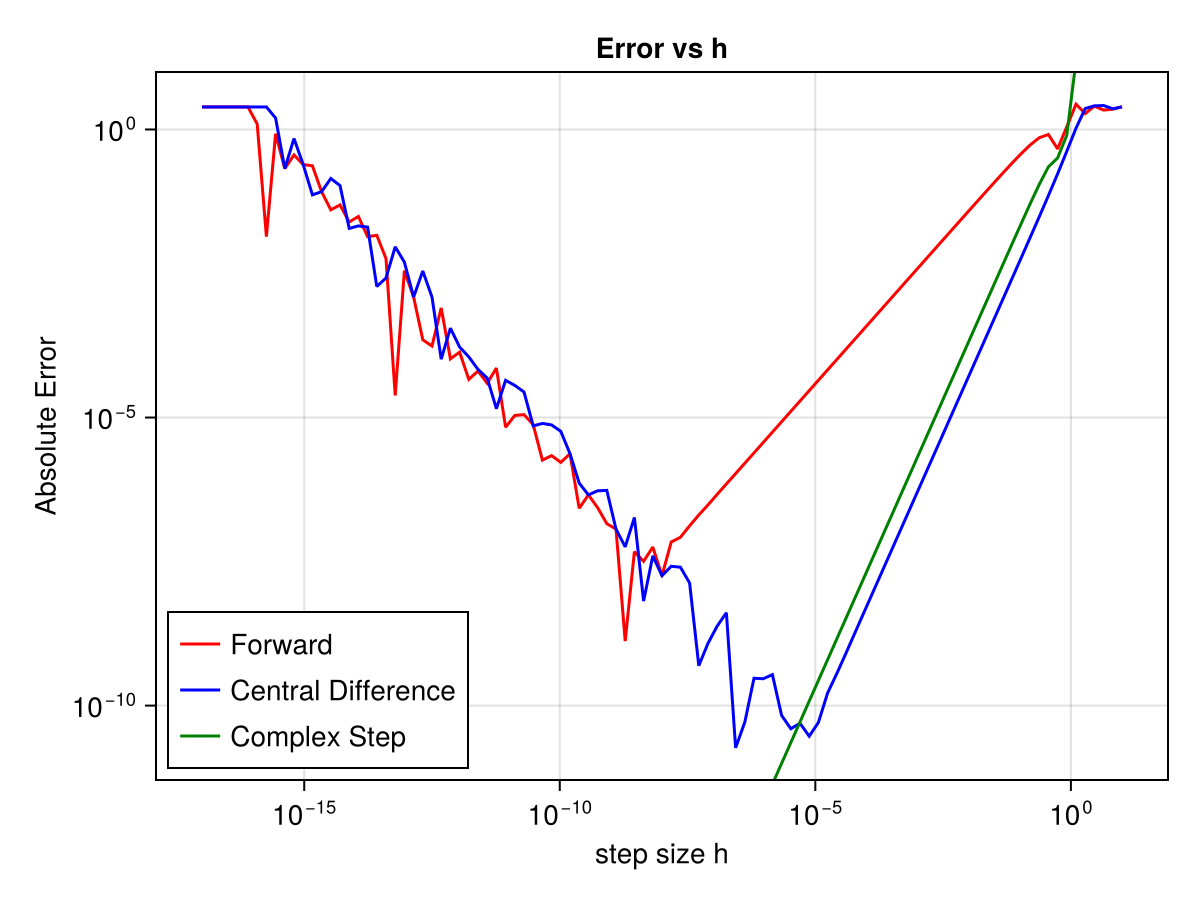

In [7]:
fig1 = Figure()
ax1 = Axis(fig1[1, 1],xscale=log10,yscale=log10,xlabel="step size h",ylabel="Absolute Error",title="Error vs h")
lines!(ax1,arr_h, arr_forward;color=:red,label="Forward")
lines!(ax1,arr_h, arr_central;color=:blue,label="Central Difference")
lines!(ax1,arr_h, arr_complex;color=:green,label="Complex Step")
axislegend( position = :lb)

fig1

From the graph above, it is clear that you can get Round Off error if $h$ is too small.   Hence, for comlex functions and for functions with lots of variables, it is not feasible to use numerical differentiation to calculate the derivatives because the truncation and round off errors will usually be too large.

In machine learning, most the derivatives is calculated using a technique called Automatic Differentiation.   In automatic differentiation, we can calculate the derivatives to machine precision very quickly and efficiently for a function with many variables.   We will go into details of what Automatic differentiation is and how it can be implemented in the next notebook.  Here, I will introduce you to some Julia packages that can perform automatic differentiation.  

# Univariate Function without any parameters

Julia has a few libraries that will compute the derivates, gradient and Hessians of a function for you.  The two packages that will be covered here are called `ForwardDiff.jl` and `Zygote.jl`   They all have slightly different syntax and  advantages and disadvantages. `ForwardDiff.jl` is probably the most straightforward to use and `Zygote.jl` is more difficult to use but it is also much faster, especially for machine learning.  I will give you examples below on how to use these packages

Using `ForwardDiff.jl` to find the derivative of $f(x)$ at $x=\pi/2$

In [8]:
ForwardDiff.derivative(f, π/2)
println("The true answer is ",d_true," ForwardDiff gives ",ForwardDiff.derivative(f, x))

The true answer is -2.4542495411512917 ForwardDiff gives -2.4542495411512917


Note above thata the ForwardDiff.derivative() gives a value of the derivative up to machine precision

Now try using `Zygote.jl` Automatic Differentiation Package

In [9]:
Zygote.gradient(f, x)
println("The true answer is ",d_true," Zygote gives ",Zygote.gradient(f, x)[1])

The true answer is -2.4542495411512917 Zygote gives -2.4542495411512917


All the derivatives given by ForwardDiff.jl and Zygote.jl are accurate down to machine precision.

Define derivative functions for all two packages

In [10]:
dfForwardDiff(x)=ForwardDiff.derivative(f, x)
dfZygote(x)=Zygote.gradient(f, x)[1]

dfZygote (generic function with 1 method)

We can evaluate and plot $df/dx$ for $-1<x<1$

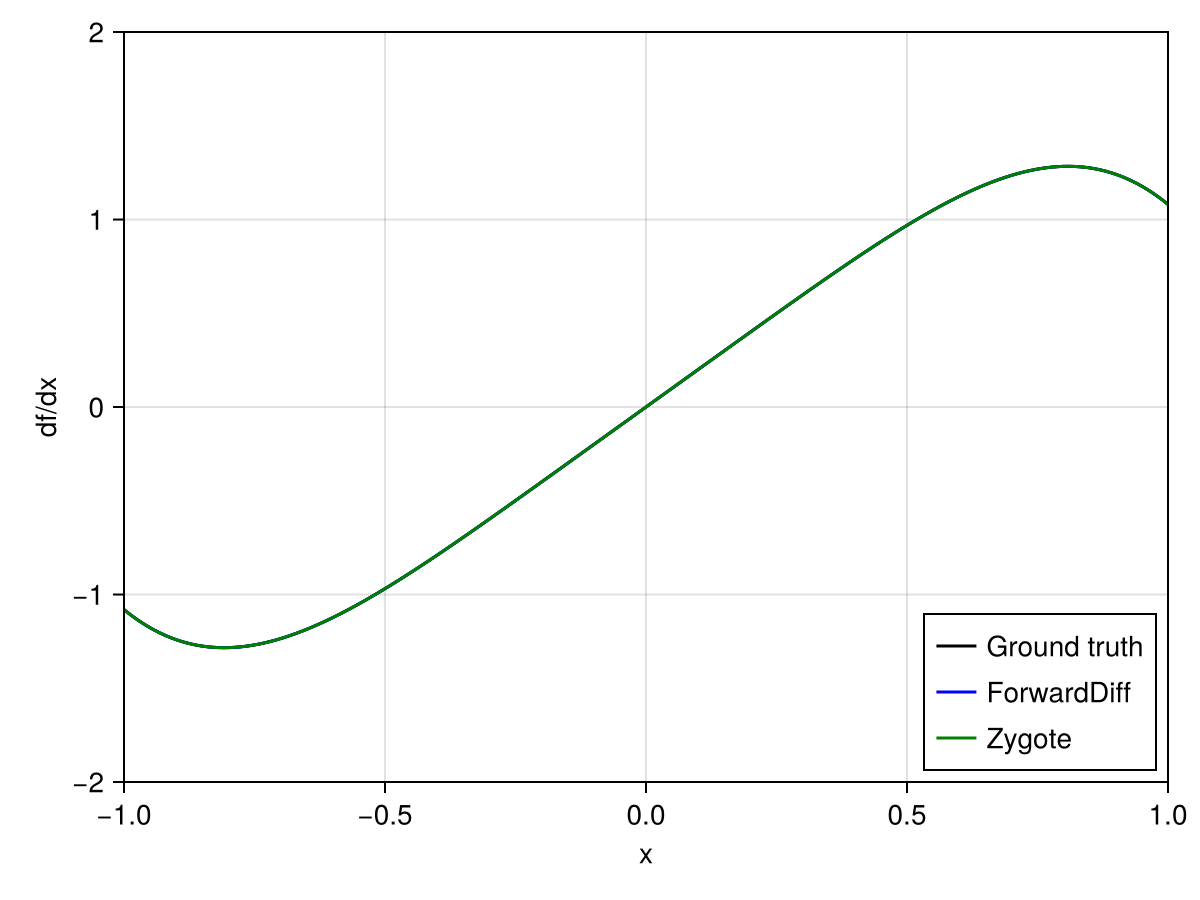

In [11]:
xplot=-1:0.01:1
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "x", ylabel = "df/dx",limits=(-1.0,1.0,-2.0,2.0))
lines!(xplot,2*xplot.*cos.(xplot.^2);color=:black,label="Ground truth")
lines!(xplot,dfForwardDiff.(xplot);color=:blue,label="ForwardDiff")
lines!(xplot,dfZygote.(xplot);color=:green,label="Zygote")

axislegend(ax,position = :rb)
fig

The plot above shows that ForwardDiff, Zygote gives exact values (to machine accuracy) of the derivatives for the whole range of $x$ values.

---
In the first week of this course, we used the Newton-Raphson method to find the zero of the function

$f(x)=4\pi x-\frac{2}{x^2}$

We used the `NonlinearSolve` in Julia to find $x$ where $f(x)=0$.  Here we will use the Newton-Raphson method but I am going to use `ForwardDiff` to calculate the derivative (so that I do not need to know how to differentiate $f(x)$!).  Recall that for this function, the value of $x$ where $f(x)=0$ is approximately $x=0.541...$.  We will use the Newton-Raphson method

$x_{i+1}=x_i-f(x_i)/f'(x_i)$


In [13]:
f2(x)=4π*x-2/x^2
x=1.0
for i=1:10
    x-=f2(x)/ForwardDiff.derivative(f2,x)
    println(x)
end

0.3621795105078358
0.4727153376004709
0.5323948682518493
0.5417564911696957
0.5419260170637374
0.5419260701392838
0.5419260701392891
0.5419260701392891
0.5419260701392891
0.5419260701392891


---

# Multivariate Function without any parameters

We will now use Enzyme to calculate the gradients of the Himmelblau function

$f(x_1,x_2)=(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2$
  

Recall that the derivatives are 



$\frac{\partial f}{\partial x_1}(x_1,x_2)=4x_1(x_1^2+x_2-11)+2(x_1+x_2^2-7)$

$\frac{\partial f}{\partial x_2}(x_1,x_2)=2(x_1^2+x_2-11)+4x_2(x_1+x_2^2-7)$

and the components of the Hessian are

$\frac{\partial^2 f}{\partial x_1^2}(x_1,x_2)=12x_1^2+4x_2-42$

$\frac{\partial^2 f}{\partial x_1 \partial x_2}(x_1,x_2)=4x_1+4x_2$

$\frac{\partial^2 f}{\partial x_2 \partial x_1}(x_1,x_2)=4x_1+4x_2$

$\frac{\partial^2 f}{\partial x_2^2}(x_1,x_2)=4x_1+12x_2^2-26$


Define the Himmelblau function

$h(x_1,x_2)=(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2$

In [17]:
himmelblau(x)=(x[1]^2+x[2]-11)^2+(x[1]+x[2]^2-7)^2

himmelblau (generic function with 1 method)

Use `ForwardDiff` to calculate the gradient of the himmelblau function at $(x_1,x_2)=(0,0)$.

In [18]:
x0 = [0.0, 0.0]
ForwardDiff.gradient(himmelblau,x0)

2-element Vector{Float64}:
 -14.0
 -22.0

<u>Exercise Ex02:</u> Try using the `Zygote.gradient()` to calculate the gradient of the himmelblau function at $(x_1,x_2)=(0,0)$

Using Gradient Descent with `ForwardDiff` to calculate the minimum of the Himmelblau function.  You can see below, I do not need to manually figure out what the gradients are.  I just use `ForwardDiff.gradient()` to calculate the (exact) graddients, $\partial h/\partial x_1$ and $\partial h/\partial x_2$ 

In [19]:
struct Point2D
    x1::Float64
    x2::Float64
    fvalue::Float64
end

x0=[-2.0,-2.0]#initial guess of x0
alpha=0.01
data_gd=[Point2D(x0...,himmelblau(x0))]

x=x0
for i in 1 : 50
    x-=alpha*ForwardDiff.gradient(himmelblau,x)
    push!(data_gd,Point2D(x...,himmelblau(x)))
end

data_gd

51-element Vector{Point2D}:
 Point2D(-2.0, -2.0, 106.0)
 Point2D(-2.62, -2.22, 62.404761919999984)
 Point2D(-3.19223488, -2.5095020800000003, 26.184856197768234)
 Point2D(-3.5381609903413658, -2.8340630130552853, 8.011765332690304)
 Point2D(-3.6742112090087837, -3.0918679875433708, 1.5927632586276927)
 Point2D(-3.7389311349776633, -3.217870523191624, 0.20441067649087527)
 Point2D(-3.7668805073219027, -3.2625626716330705, 0.020376679773417165)
 Point2D(-3.7754546966932847, -3.2770942749729803, 0.0018344361969869342)
 Point2D(-3.778211411814951, -3.281366700658341, 0.00015965025359141713)
 Point2D(-3.778974634603722, -3.282660320088421, 1.3752814215095311e-5)
 ⋮
 Point2D(-3.779310253377747, -3.283185991286169, 7.888609052210118e-31)
 Point2D(-3.779310253377747, -3.283185991286169, 7.888609052210118e-31)
 Point2D(-3.779310253377747, -3.283185991286169, 7.888609052210118e-31)
 Point2D(-3.779310253377747, -3.283185991286169, 7.888609052210118e-31)
 Point2D(-3.779310253377747, -3.28318599128

The method of gradient descent converges to $(x_1,x_2)\approx (-3.779...,-3.283...)$

---

# Function with parameters

We will now illustrate how you can use `ForwardDiff` or `Zygote` packages to calculate derivatives of  function with many parameters.   The important thing to note is that `ForwardDiff` can only differentiate functions with one argument.  So if you have a function with many input, you need to turn it into a function with just one input. The one input can be a vector.   The `Zygote` package can differentiate with respect to many variables (inputs).


First, define a function with two parameters $W$ and $b$

$NN(x;W,b)=\sin(Wx+b)$

In [24]:
function NN(x,W,b)
    sin(W*x+b)
end

NN (generic function with 1 method)

`ForwardDiff` will fail if you try to use it on $NN(x,W,b)$.  Try finding the gradient of $NN$ with respect to $x$, $W$ and $b$ at $x=1$, $W=2$ and b=3$

In [45]:
ForwardDiff.gradient(NN,1,2,3)

MethodError: MethodError: no method matching gradient(::typeof(NN), ::Int64, ::Int64, ::Int64)
The function `gradient` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  gradient(::Any, ::Real)
   @ ForwardDiff ~/.julia/packages/ForwardDiff/4J2wz/src/gradient.jl:46
  gradient(::F, !Matched::StaticArraysCore.StaticArray) where F
   @ ForwardDiffStaticArraysExt ~/.julia/packages/ForwardDiff/4J2wz/ext/ForwardDiffStaticArraysExt.jl:36
  gradient(::F, !Matched::StaticArraysCore.StaticArray, !Matched::ForwardDiff.GradientConfig) where F
   @ ForwardDiffStaticArraysExt ~/.julia/packages/ForwardDiff/4J2wz/ext/ForwardDiffStaticArraysExt.jl:37
  ...


Calculating $\frac{\partial NN}{\partial x} (x=1,W=2,b=3)=W\cos(Wx+b)=2\cos(2+3)=0.5673243709264525$


In [51]:
ForwardDiff.derivative((x)->NN(x,2,3),1.0)

0.5673243709264525

Calculating $\frac{\partial NN}{\partial W} (x=1,W=2,b=3)=x\cos(Wx+b)=1\cos(2+3)=0.28366218546322625$

In [48]:
ForwardDiff.derivative((W)->NN(1,W,3),2.0)

0.28366218546322625

Calculating $\frac{\partial NN}{\partial b} (x=1,W=2,b=3)=\cos(Wx+b)=1\cos(2+3)=0.28366218546322625$

In [52]:
ForwardDiff.derivative((b)->NN(1,2,b),3.0)

0.28366218546322625

Or you can just use the `Zygote` package

In [53]:
Zygote.gradient(NN,1,2,3)

(0.5673243709264525, 0.28366218546322625, 0.28366218546322625)

You can also use the packages to calculate 2nd derivatives. The code below uses the  `Zygote` package to calculate the 1st and 2nd derivatives of *NN* with respect to *x*. In the code below, we have used $W=1$ and $b=1$.  NNd1 is the first derivative and NNd2 is the 2nd derivagive. 

In [56]:
W=1
b=0
NNd1=(x)->Zygote.gradient(NN,x,W,b)[1]
NNd2=(x)->Zygote.gradient(NNd1,x)[1]

#76 (generic function with 1 method)

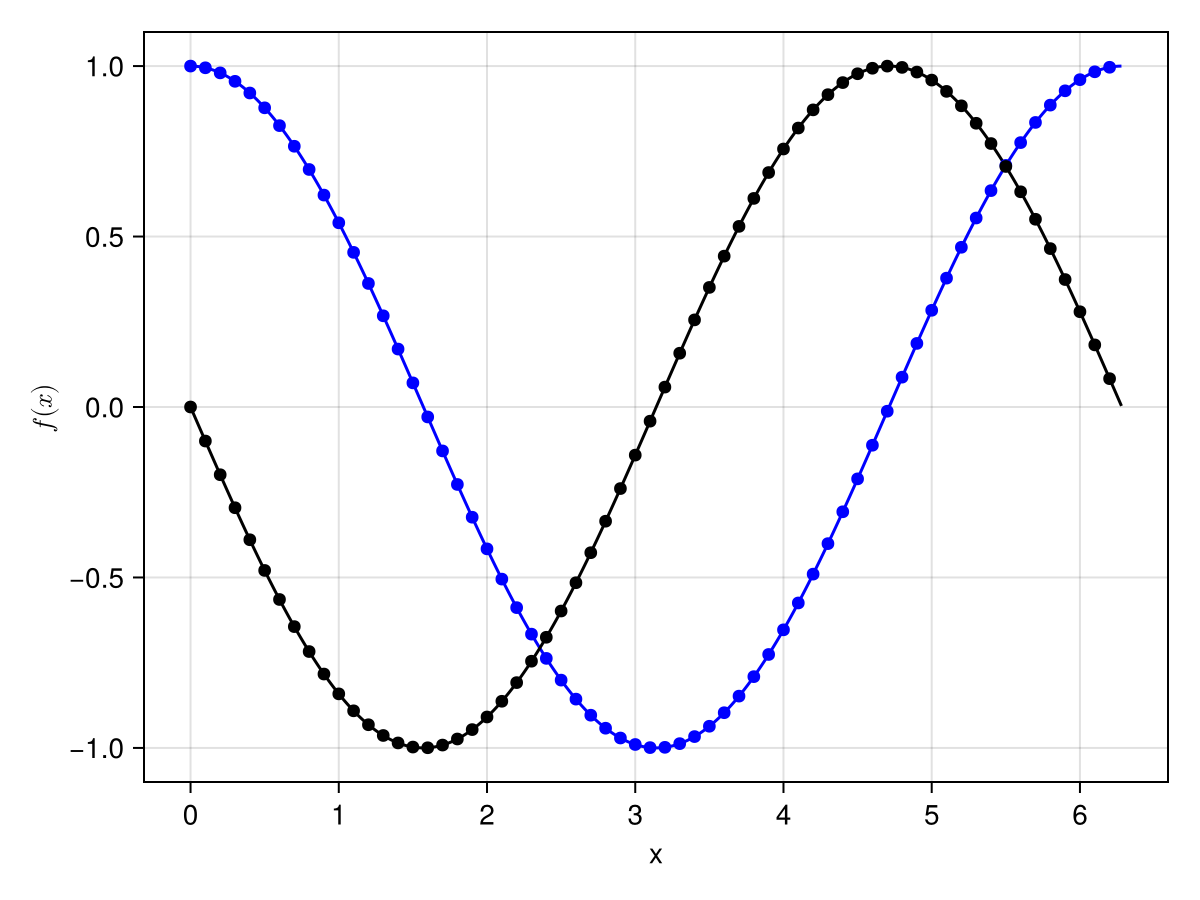

In [57]:
xplot=Array(0:0.01:2π)

xdata=Array(0:0.1:2π)
W=1.0
b=0.0
fig = Figure()
ax = Axis(fig[1, 1],xlabel = "x", ylabel = L"f(x)")
lines!(ax,xplot,NNd1.(xplot);color=:blue)
lines!(ax,xplot,NNd2.(xplot);color=:black)

scatter!(ax,xdata,W*cos.(W*xdata.+b);color=:blue)
scatter!(ax,xdata,-W*W*sin.(W*xdata.+b);color=:black)

fig

---

In Notebook 3.5, we used the `Optimisation()` package in Julia to find the parameters of the model function  

$f_{model}(x)=a_1(1-e^{a_2x})$

to fit a fictitous dataset.  In this section of the notebook, we will get a better insight on what the `Optimisation()` package is doing.  

Let's generate the fictitious dataset (again!) and plot the data to see how it looks like.

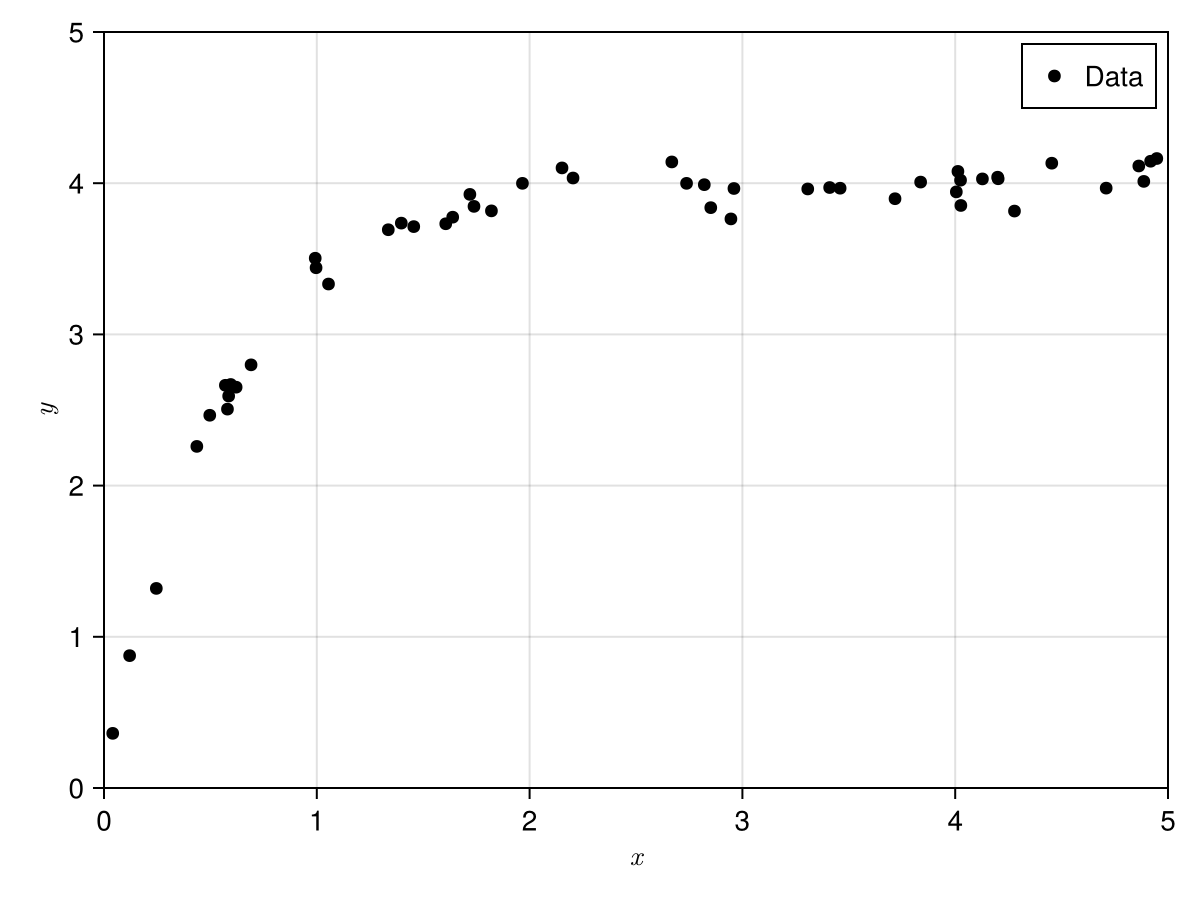

In [ ]:
N_SAMPLES=50 #50 data points
rng=Xoshiro(1) #my random number generator

x_samples=rand(rng,Uniform(0,5),N_SAMPLES) #generate random values of x between -1 and 1
y_noise=rand(rng,Normal(0.0,0.1),N_SAMPLES) #generate some noise, normal distribution with standard deviation of 0.1
y_samples=4*(1.0.-exp.(-1.8*x_samples))+y_noise;

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(0,5,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
axislegend(ax;position = :rt)
fig

Define the model 

$f_{model}(\vec{a},x)=a_1(1-e^{a_2x})$

We will also define a custom loss function

$S=\frac{1}{2}\sum\limits_{i=1}^{N} \left(y_i-f_{model}(\vec{a},x_i)\right)^2$

The idea is to find $a_1$ and $a_2$ such that we make $S$ as small as possible. We will use standard gradient descent. To use this method, we need to find gradient $\frac{\partial S}{\partial a_1}$ and $\frac{\partial S}{\partial a_2}$ and we will use automatic differentiation to calculate the gradient.

We will define the model and the loss function.  

In [59]:
fmodel(a,x)=a[1]*(1.0.-exp.(a[2]*x)); # for this model a[1]=a and a[2]=b.
function custom_loss(parameters,x_samples)
           ŷ = fmodel(parameters, x_samples)
           0.5*sum((y_samples .- ŷ).^2)
end
a=[1.0,-1.0] #initial assumptions of the values of  a0, a1 

2-element Vector{Float64}:
  1.0
 -1.0

We will define a function $S$  that is just a function of $\vec{a}$.  Then we use `Zygote()` to calculate the gradient with respect to $\vec{a}$, $\partial S/\partial a_1$ and $\partial S/\partial a_2$

In [60]:
S=(a)->custom_loss(a,x_samples)
Zygote.gradient(S, a)[1]

2-element Vector{Float64}:
 -113.90018346559744
   25.972734381952076

Use gradient descent to minimize $S(\vec{a})$

In [61]:
α=0.01 #learning rate
for i=1:500
    a-=α * Zygote.gradient(S,a)[1]
    println(a)
end

[2.1390018346559745, -1.2597273438195207]
[2.8987269538320937, -1.4969371995729637]
[3.366404392779467, -1.6375194285298376]
[3.642257471617602, -1.7181989633830088]
[3.801882722998297, -1.7641794083694813]
[3.8933764991482684, -1.7903362982424835]
[3.945553758140763, -1.8052169571373649]
[3.9752248457675963, -1.813693557831972]
[3.992068343102892, -1.8185351132858958]
[4.001618185207118, -1.8213133617986053]
[4.007026598148098, -1.8229199449951736]
[4.01008539004146, -1.8238605712596616]
[4.011811873303483, -1.8244220518462573]
[4.012783245965075, -1.8247670723103537]
[4.013326865565147, -1.8249879405206282]
[4.013628345180858, -1.825137062221884]
[4.013792907451754, -1.825244218956136]
[4.013880190430729, -1.8253263631367602]
[4.013923987015601, -1.8253931709079485]
[4.013943437907328, -1.8254501901135394]
[4.0139493778059725, -1.8255006249787296]
[4.013947933376313, -1.8255463479755794]
[4.0139425630297305, -1.8255884735945358]
[4.013935213293178, -1.82562768376534]
[4.0139269743406

Once we have found the optimum values of $a_1$ and $a_2$, we can plot the model.

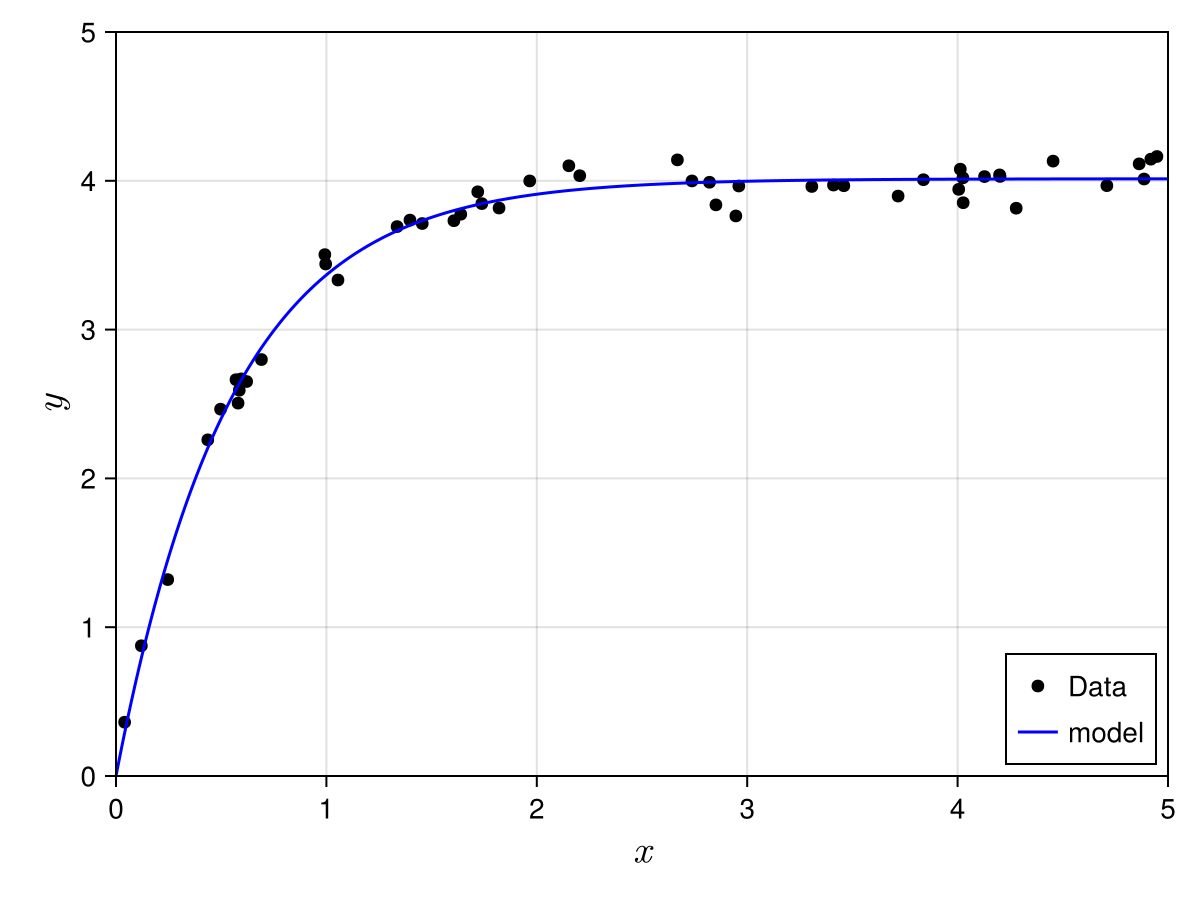

In [62]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(0,5,0,5),
    xlabelsize = 20, # Set X label size
    ylabelsize = 20) 
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
lines!(ax,xplot,fmodel(a,xplot);label="model",color=:blue)
axislegend(ax;position = :rb)
fig

Good agreement!

---
# Vector (vector-valued) functions  of vector
#
Vector functions are a collection of scalar valued functions of many variables.  For many applications, you have a vector functions that you need to differentiate. I will illustrate the derivative of vector functions with the example below

$\vec{f}(\vec{x})$

$f_i(\vec{x})=\begin{cases}x_i-1 & i=1\\
x_i-x_{i-1}^2 & i=2..N-1\\
x_i-x_{i-1} & i=N
\end{cases}$

For $N=5$, and if we assume that $x_1=x_2=x_3=x_4=x_5=2$ this function looks like

$$
\begin{Bmatrix}
f_1(x_1,x_2,x_3,x_4,x_5)\\
f_2(x_1,x_2,x_3,x_4,x_5)\\
f_3(x_1,x_2,x_3,x_4,x_5)\\
f_4(x_1,x_2,x_3,x_4,x_5)\\
f_5(x_1,x_2,x_3,x_4,x_5)
\end{Bmatrix}=\begin{Bmatrix}
x_1-1 \\
x_2-x_1^2\\
x_3-x_2^2\\
x_4-x_3^2\\
x_5-x_4
\end{Bmatrix}=\begin{Bmatrix}
1 \\
-2\\
-2\\
-2\\
0
\end{Bmatrix}
$$

The Jacobian of vector functions, is defined as the derivative of each component of the vector with respect to each variable.  For example, the Jacobian $\partial \vec{f}/\partial \vec{x}$ for $N=5$ is a $5\times 5$ matrix.  If $x_1=x_2=x_3=x_4=x_5=2$

$$
\partial \vec{f}/\partial \vec{x}=\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} &  \frac{\partial f_1}{\partial x_2} & \frac{\partial f_1}{\partial x_3} & \frac{\partial f_1}{\partial x_4} & \frac{\partial f_1}{\partial x_5}\\
\frac{\partial f_2}{\partial x_1} &  \frac{\partial f_2}{\partial x_2} & \frac{\partial f_2}{\partial x_3} & \frac{\partial f_2}{\partial x_4} & \frac{\partial f_2}{\partial x_5}\\
\frac{\partial f_3}{\partial x_1} &  \frac{\partial f_3}{\partial x_2} & \frac{\partial f_3}{\partial x_3} & \frac{\partial f_3}{\partial x_4} & \frac{\partial f_3}{\partial x_5}\\
\frac{\partial f_4}{\partial x_1} &  \frac{\partial f_4}{\partial x_2} & \frac{\partial f_4}{\partial x_3} & \frac{\partial f_4}{\partial x_4} & \frac{\partial f_4}{\partial x_5}\\
\frac{\partial f_5}{\partial x_1} &  \frac{\partial f_5}{\partial x_2} & \frac{\partial f_5}{\partial x_3} & \frac{\partial f_5}{\partial x_4} & \frac{\partial f_5}{\partial x_5}\\
\end{bmatrix}=
$$
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
-2x_1 & 1 & 0 & 0 & 0\\
0 & -2x_2 & 1 & 0 & 0\\
0 & 0 & -2x_3 & 1 & 0\\
0 & 0 & 0 & -1 & 1\\
\end{bmatrix}=$$

\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
-4 & 1 & 0 & 0 & 0\\
0 & -4 & 1 & 0 & 0\\
0 & 0 & -4 & 1 & 0\\
0 & 0 & 0 & -1 & 1\\
\end{bmatrix}
$$

I will now show how you can use `Zygote` or `ForwardDiff` to find the Jacobian of a $\vec{f}(\vec{x})$.  First we need to define $\vec{f}$.  In the example below, I will define $\vec{f}$ in two different ways, in the function `fvec1()` and `fvec1()`.  You will see that only one of them can be differentiated using `Zygote` and both of them works with `ForwardDiff`.

In [63]:
function fvec1(x)
    df=similar(x)
    df[1]=x[1]-1
    for i=2:length(x)-1
        df[i]=x[i]-x[i-1]^2
    end
    df[end]=x[end]-x[end-1]
    return df
end

fvec1 (generic function with 1 method)

In [64]:
fvec2(x)=[x[1]-1;
x[2:end-1].-x[1:end-2].^2;
x[end]-x[end-1]]

fvec2 (generic function with 1 method)

In [68]:
N=5
x=2*ones(N)
fvec1(x)

5-element Vector{Float64}:
  1.0
 -2.0
 -2.0
 -2.0
  0.0

In [69]:
fvec1(x).-fvec2(x)

5-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0

`fvec1()` and `fvec2()` are exactly the same function.  However, you will see in the code below that one of them can be differentiated using `Zygote` but both of them works with `ForwardDiff`.

Now we use Zygote to find the Jacobian of $\vec{f}(\vec{x})$

In [70]:
Zygote.jacobian(fvec1,x)[1]

ErrorException: Mutating arrays is not supported -- called setindex!(Vector{Float64}, ...)
This error occurs when you ask Zygote to differentiate operations that change
the elements of arrays in place (e.g. setting values with x .= ...)

Possible fixes:
- avoid mutating operations (preferred)
- or read the documentation and solutions for this error
  https://fluxml.ai/Zygote.jl/latest/limitations


In [53]:
Zygote.jacobian(fvec2,x)[1]

5×5 Matrix{Float64}:
  1.0   0.0   0.0   0.0  0.0
 -4.0   1.0   0.0   0.0  0.0
  0.0  -4.0   1.0   0.0  0.0
  0.0   0.0  -4.0   1.0  0.0
  0.0   0.0   0.0  -1.0  1.0

In [54]:
ForwardDiff.jacobian(fvec1,x)

5×5 Matrix{Float64}:
  1.0   0.0   0.0   0.0  0.0
 -4.0   1.0   0.0   0.0  0.0
  0.0  -4.0   1.0   0.0  0.0
  0.0   0.0  -4.0   1.0  0.0
  0.0   0.0   0.0  -1.0  1.0

In [71]:
ForwardDiff.jacobian(fvec2,x)

5×5 Matrix{Float64}:
  1.0   0.0   0.0   0.0  0.0
 -4.0   1.0   0.0   0.0  0.0
  0.0  -4.0   1.0   0.0  0.0
  0.0   0.0  -4.0   1.0  0.0
  0.0   0.0   0.0  -1.0  1.0

The reason is because `Zygote` does not allow the array created inside the function to be mutated.  In `fvec1()` the variable *df* is created inside the function and then mutated (changed).  Because of the algorithm the `Zygote` uses, array mutation inside the function is not allowed. 

---

Recall in the first week that we used `NonlinearSolve()` to find the solution to the two equations below

\begin{align}
u(x,y)&= x^2 -y+ 1=0\\
v(x,y)&=3\cos(x)-y=0
\end{align}

We derived the Newton-Raphson formula

$\begin{bmatrix}
   {u_x } & {u_y }   \\
   {v_x } & {v_y }   \\
\end{bmatrix}$ 
$\begin{Bmatrix}
   {x_{i + 1}  - x_i }  \\
   {y_{i + 1}  - y_i }  
\end{Bmatrix} 
=$
$-\begin{Bmatrix}
   u  \\
   v 
\end{Bmatrix}$

In order to use the `ForwardDiff()` , it is more convenient to change the notation and write the above equations as

$
\begin{align}
f_1(\vec{x})&= x_1^2 -x_2+ 1=0\\
f_2(\vec{x})&=3\cos(x_1)-x_2=0
\end{align}
$

$
\begin{bmatrix}
   {\partial f_1/\partial x_1 } & {\partial f_1/\partial x_2  }   \\
   {\partial f_2/\partial x_1 } & {\partial f_2/\partial x_2  }   \\
\end{bmatrix}
\begin{Bmatrix}
   x_1^{(i + 1)}  - x_1^{(i) }  \\
   x_2^{(i + 1)}  - x_2^{(i) }  
\end{Bmatrix} 
=-\begin{Bmatrix}
   f_1(x_1^{(i) } ,x_2^{(i) } )  \\
   f_2(x_1^{(i) } ,x_2^{(i) } ) 
\end{Bmatrix}$


In the first week, we calculated the Jacobian by hand.  Here we will use `ForwardDiff` to calculate the Jacobian

In [73]:
VectorFunc(x)=[x[1]^2-x[2]+1,
                3*cos(x[1])-x[2]]

VectorFunc (generic function with 1 method)

You can calculate the Jacobian by using `ForwardDiff.jacobian()`.  In the example below, we evalueate the Jacobian at $(x_1,x_2)=(1,1)$

In [74]:
ForwardDiff.jacobian(VectorFunc,[1,1])

2×2 Matrix{Float64}:
  2.0      -1.0
 -2.52441  -1.0

Now using Newton-Raphson formula

In [77]:
x=[1,1]
for i=1:5
    F=VectorFunc(x)
    J=ForwardDiff.jacobian(VectorFunc,x)
    delta=-J\F
    x+=delta
    println(x)
end

[0.9162116530444182, 1.8324233060888364]
[0.9131363112988626, 1.8338084652856412]
[0.9131320007943952, 1.8338100508561948]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]
